# **Image Reconstruction**

In [1]:
# Own modules
from src.utils import show_image, seed_all, MAE, save_model, load_model
from src.data_processing import download_dataset, get_dataset
from src.zhang_model import ZhangColorizationNet
from src.train import train
from src.evaluate import validate_zhang
from src.predict import predict_image_zhang


# Other libraries
import warnings
import os
import torch
import numpy as np
from tqdm import tqdm

# Paths
IMAGES_PATH = "images/"
DATA_PATH = "data/"
MODELS_PATH = "models/"
TEST_IMAGE_PATH = "data/test"

# seed
seed = 42
seed_all(seed)

d:\Aplicaciones\Python_3_12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CONSTANTS
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Loss is weighted cross entropy loss
HYPERPARAMETERS = {
    "size": (256, 256),  # Image size
    "output_classes": 313, # quantized ab bins
    "optimizer": "sgd",  # Optimizer
    "learning_rate": 1e-3,  # Learning rate
    "momentum": 0.9,  # Momentum
    "batch_size": 64,  # Batch size
    "epochs": 2,  # Number of epochs
    "num_workers": 4,  # Number of workers for data loading
    "scheduler": "StepLR",  # Learning rate scheduler
    "scheduler_step_size": 2,  # Step size for the scheduler
    "scheduler_gamma": 0.1,  # Gamma for the scheduler
}

**Loading the data**

In [4]:
train_dataset, val_dataset = get_dataset(DATA_PATH, HYPERPARAMETERS["size"], 0.1, "CIELab")

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
train_dataset.image_paths

Train dataset size: 8
Validation dataset size: 7


['data/train_test\\000000000036.jpg',
 'data/train_test\\000000000049.jpg',
 'data/train_test\\000000000061.jpg',
 'data/train_test\\000000000074.jpg',
 'data/train_test\\000000000077.jpg',
 'data/train_test\\000000000086.jpg',
 'data/train_test\\000000000109.jpg',
 'data/train_test\\000000000110.jpg']

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=True,
    num_workers=HYPERPARAMETERS["num_workers"],
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=False,
    num_workers=HYPERPARAMETERS["num_workers"],
)


**Create the pts_in_hull file**

In [6]:
# Lets create the points in hull file
train_dataset.get_pts_in_hull()

array([[ 9.76944119e-01, -2.98983340e-01],
       [-1.55693034e+01,  3.14069922e+01],
       [ 4.02272403e+01, -9.53585037e+00],
       [ 2.42258772e+00,  8.74014767e+00],
       [-6.23079704e+00, -2.52337936e+01],
       [ 1.41869980e+01,  3.52696819e+01],
       [-3.26094519e+01,  4.34378979e+01],
       [-1.60084469e+01, -1.15728929e+00],
       [-7.46092910e+00,  1.19965598e+01],
       [ 1.67102484e+01,  1.50402589e+01],
       [-4.47682163e+00, -6.36837399e+00],
       [ 5.10295258e+00, -1.27362617e+01],
       [ 4.83142099e+00,  2.03894221e+01],
       [-4.24349958e+00,  5.09617088e+00],
       [-9.56203280e+00,  2.31783931e+01],
       [ 2.45196215e+01, -1.88475350e+01],
       [-2.30980441e+01, -1.76133893e+01],
       [-2.33977636e+01,  4.05815585e+01],
       [ 1.10907235e+01,  1.03366272e+01],
       [ 2.48028176e+01,  6.35854312e+00],
       [ 2.30035911e+01,  5.48331529e+01],
       [-2.04298779e+01,  1.54837056e+01],
       [ 5.68869753e+01, -8.41467432e+00],
       [ 9.

In [7]:
Q = 313
bin_counts = np.zeros(Q)

for i in tqdm(range(len(train_dataset)), desc="Computing class frequencies"):
    _, label_map = train_dataset[i]  # label_map is (H, W), with class indices 0–312
    label_flat = label_map.numpy().flatten()  # shape: (H*W,)
    
    for idx in label_flat:
        bin_counts[idx] += 1

# Normalize to get empirical distribution
p_q = bin_counts / np.sum(bin_counts)

# Apply Zhang's smoothing formula
lambda_val = 0.5
w_q = (1 - lambda_val) * p_q + (lambda_val / Q)

# Invert and normalize
weights = 1 / w_q
weights = weights / (np.sum(weights) * Q)

# Save the weights
np.save("class_weights.npy", weights)


Computing class frequencies: 100%|██████████| 8/8 [00:00<00:00,  8.03it/s]


In [8]:
weights.shape

(313,)

**Train the model**

In [9]:
model = ZhangColorizationNet(
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=HYPERPARAMETERS["learning_rate"],
)
if HYPERPARAMETERS["scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=HYPERPARAMETERS["scheduler_step_size"],
        gamma=HYPERPARAMETERS["scheduler_gamma"],
    )

# cross entropy loss with class weights
criterion = torch.nn.CrossEntropyLoss(
    weight=torch.from_numpy(weights).float().to(device),
    ignore_index=0,
)


In [13]:
model, train_hist, val_hist = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=HYPERPARAMETERS["epochs"],
    scheduler=scheduler,
    device=device,
)



d:\Aplicaciones\Python_3_12\Lib\site-packages\torch\optim\lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 1/2 completed in 46.65s
  Train Loss: 5.7476
  Validation Loss: 5.7447



Epoch 2/2 completed in 37.11s
  Train Loss: 5.7150
  Validation Loss: 5.7452


In [18]:
# Create a random name for the model
import random
import string
import datetime
MODEL_NAME = "colorization_model_zhang" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + ''.join(random.choices(string.ascii_lowercase, k=5))
# Save the model
save_model(model, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME, HYPERPARAMETERS)

Model saved at models/colorization_model_zhang20250420_104819_fnafq/colorization_model_zhang20250420_104819_fnafq.pth
Model parameters saved at models/colorization_model_zhang20250420_104819_fnafq/colorization_model_zhang20250420_104819_fnafq_params.json


In [10]:
MODEL_NAME = "colorization_model_zhang20250420_104819_fnafq"

In [11]:

# Load the model
model2 = ZhangColorizationNet().to(device)
model, _ = load_model(model2, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME)



d:\Documentos\Carnegie Mellon\Courses\Applied Deep Learning\Project\image_reconstruction\src\utils.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict

**Prediction**

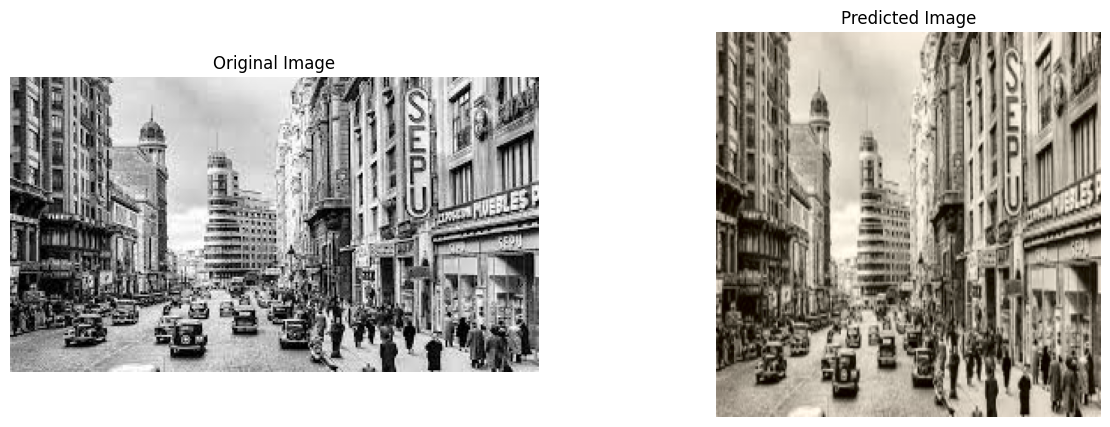

PermissionError: [Errno 13] Permission denied: 'D:\\Documentos\\Carnegie Mellon\\Courses\\Applied Deep Learning\\Project\\image_reconstruction\\models\\pred_old_madrid.jpeg'

<Figure size 640x480 with 0 Axes>

In [12]:
test_image = "old_madrid.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

# pass a path that saves the image in the models folder
show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))


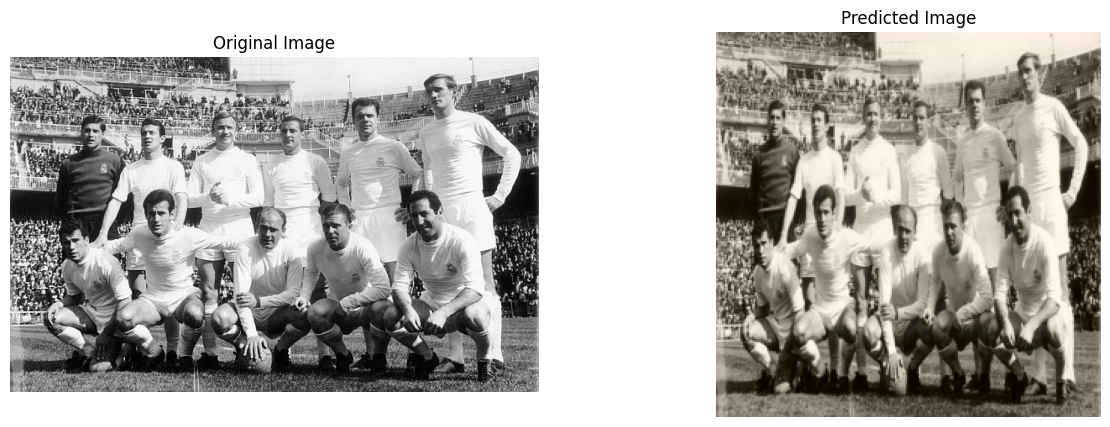

PermissionError: [Errno 13] Permission denied: 'D:\\Documentos\\Carnegie Mellon\\Courses\\Applied Deep Learning\\Project\\image_reconstruction\\models\\pred_real_madrid.jpg'

<Figure size 640x480 with 0 Axes>

In [14]:
test_image = "real_madrid.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))

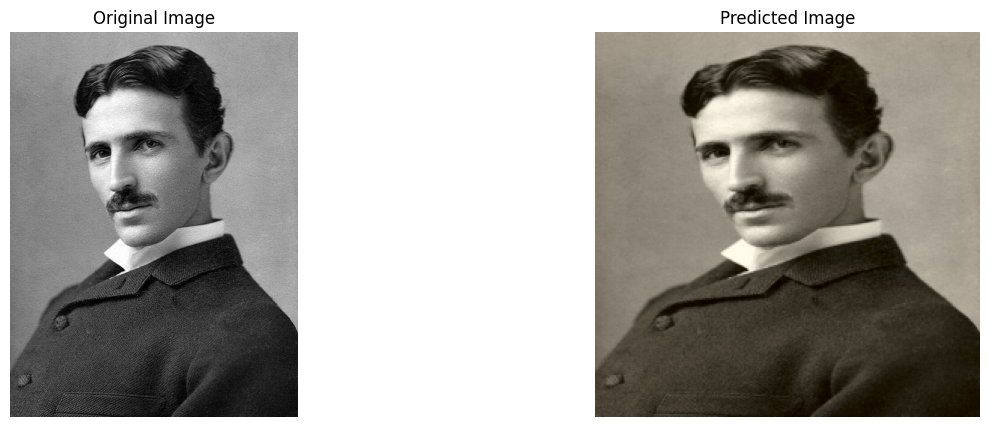

PermissionError: [Errno 13] Permission denied: 'D:\\Documentos\\Carnegie Mellon\\Courses\\Applied Deep Learning\\Project\\image_reconstruction\\models\\pred_tesla.jpeg'

<Figure size 640x480 with 0 Axes>

In [15]:
test_image = "tesla.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))

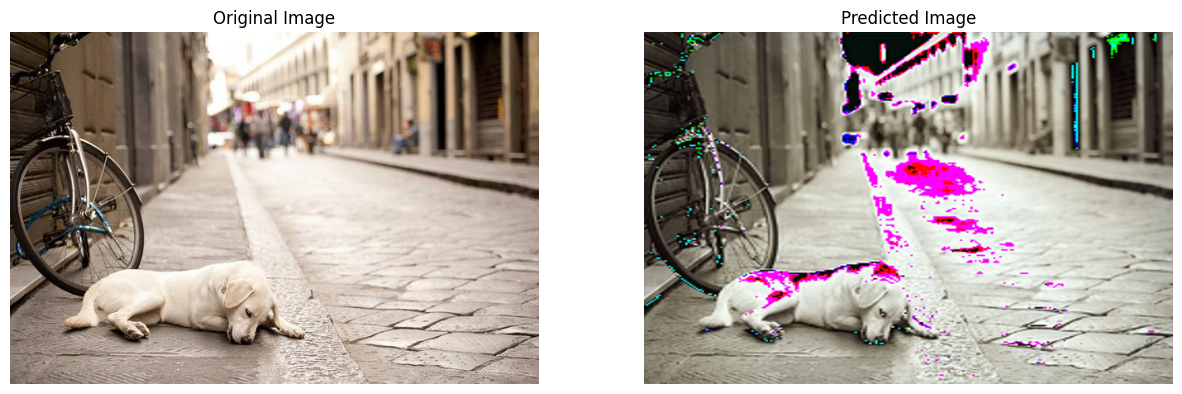

In [15]:
test_image = "dog.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))